## Here we will build ML project to predict Company Reviews between:
### {-1: negative, 0: neutral, 1: positive}

#### We will use two different appraches:
- Classeical NLP approach (Tf-IDF + classical ML models)
- pretrained encoder-transformer

## Libraries

In [61]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.6 MB/s eta 0:00:00


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('punkt_tab')
import emoji
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,recall_score,precision_score
from scipy.sparse import hstack
import numpy as np

# Load Data & investigation

In [79]:
df=pd.read_csv('CompanyReviews.csv')
df.head()

,Unnamed: 0,review_description,rating,company
0,0,رائع,1,talbat
1,1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [80]:
df.drop('Unnamed: 0',axis=1,inplace=True)
df.head()

,review_description,rating,company
0,رائع,1,talbat
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40046 entries, 0 to 40045
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  40045 non-null  object
 1   rating              40046 non-null  int64 
 2   company             40046 non-null  object
dtypes: int64(1), object(2)
memory usage: 938.7+ KB


In [82]:
df.shape

(40046, 3)

In [83]:
df.isnull().sum()

,0
review_description,1
rating,0
company,0


In [84]:
df.dropna(inplace=True)
df.isnull().sum()

,0
review_description,0
rating,0
company,0


In [85]:
df.duplicated().sum()

np.int64(28)

In [86]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## EDA

### Number of Ratings

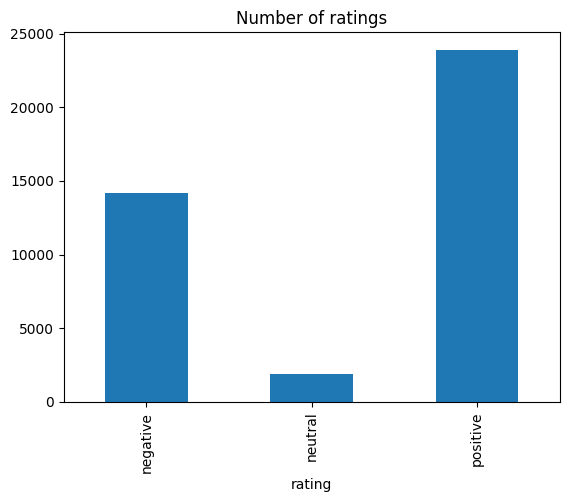

In [87]:
counts = df['rating'].value_counts().sort_index()

counts.plot(kind='bar')

plt.title('Number of ratings')
plt.xticks(ticks=[0, 1, 2], labels=['negative', 'neutral', 'positive'])

plt.show()

Imbalance classes

### Distribution of Classes

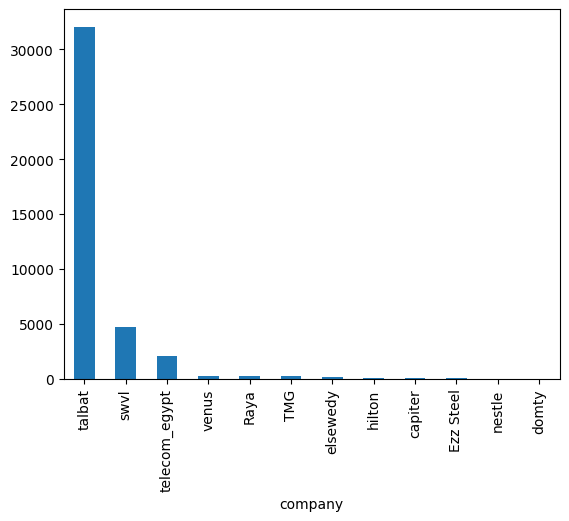

In [88]:
df['company'].value_counts().plot(kind='bar')
plt.show()

The reviews come from different Fields, almost all come from Food review (talabat)

### Review labels (check if there is mistakes)

In [58]:
df=pd.read_csv(r'data/1-df_eda.csv')

#### Check Pos labels

In [59]:
df[df['rating']==1].head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
0,رائع,1,talbat,0,0,1,0,0,1,1.000000,0.0,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.000000,0.0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...
6,جميل جدا رائع. . .,1,talbat,0,0,5,0,3,3,1.666667,0.0,جميل جدا رائع. . .
9,كتير في تحسن خدمة العملاء لطفين في بعض الاخطاء...,1,talbat,0,0,24,0,0,1,24.000000,0.0,كتير في تحسن خدمة العملاء لطفين في بعض الاخطاء...
10,ممتاز,1,talbat,0,0,1,0,0,1,1.000000,0.0,ممتاز


#### Check Negative labels

In [60]:
df[df['rating']==-1].head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...
5,أصبح غالي جداً,-1,talbat,0,0,3,0,0,1,3.0,0.0,أصبح غالي جداً
7,للأسف الواحد ينصدم بعد زيادة الاسعار و للاسف ب...,-1,talbat,0,0,13,0,0,1,13.0,0.0,للأسف الواحد ينصدم بعد زيادة الاسعار و للاسف ب...


#### Check Neutral lables

In [61]:
df[df['rating']==0].head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
45,تجربه مرضيه والتوصيل كان كويس ومعقول,0,talbat,0,0,6,0,0,1,6.0,0.0,تجربه مرضيه والتوصيل كان كويس ومعقول
50,بصراحة تغيير كبير في سياسة طلبات مع الزبائن، ه...,0,talbat,0,0,41,1,1,1,41.0,0.0,بصراحة تغيير كبير في سياسة طلبات مع الزبائن، ه...
56,لماذة لا استطيع استخدام القسائم,0,talbat,0,0,5,0,0,1,5.0,0.0,لماذة لا استطيع استخدام القسائم
66,جيد جدا,0,talbat,0,0,2,0,0,1,2.0,0.0,جيد جدا
73,3w2d32d32,0,talbat,3,1,1,0,0,1,1.0,3.0,3w2d32d32


- --> Here there is problem with neutral labels--> they are mislablesd alot
- --> I will fix that with AI annotator tools and review the results manually to check splving the probelm

### Load fixed Labeled data

In [62]:
## orignal distribution

df['rating'].value_counts()

rating
 1    23897
-1    14196
 0     1924
Name: count, dtype: int64

In [55]:
df=pd.read_csv(r'data/1-df_fixed.csv')
df.head()

,Unnamed: 0,new_rating,decoded_emojis
0,45,1,تجربه مرضيه والتوصيل كان كويس ومعقول
1,50,1,بصراحة تغيير كبير في سياسة طلبات مع الزبائن، ه...
2,56,-1,لماذة لا استطيع استخدام القسائم
3,66,1,جيد جدا
4,73,0,3w2d32d32


#### code to edit this problem

In [66]:
df_eda = pd.read_csv(r'data/1-df_eda.csv')
df_fixed = pd.read_csv(r'data/1-df_fixed.csv')

# Build lookup: {original_eda_index -> new_rating}
rating_map = df_fixed.set_index('Unnamed: 0')['new_rating'].to_dict()

# For each row in df_eda where rating==0, check if its index exists in rating_map
for idx in df_eda[df_eda['rating'] == 0].index:
    if idx in rating_map and rating_map[idx] != 0:
        df_eda.loc[idx, 'rating'] = rating_map[idx]

In [69]:
df_eda['rating'].value_counts()

rating
 1    24223
-1    15373
 0      421
Name: count, dtype: int64

In [70]:
df_eda[df_eda['rating']==0].head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
73,3w2d32d32,0,talbat,3,1,1,0,0,1,1.0,3.0,3w2d32d32
106,قءىقءء٣خغءسص٢٣_€/'٣،ب١ص٢ص,0,talbat,0,0,1,0,3,1,1.0,0.0,قءىقءء٣خغءسص٢٣_€/'٣،ب١ص٢ص
173,لدى مطعم تجهيز فى المنزل اريد التواصل معكم,0,talbat,0,0,8,0,0,1,8.0,0.0,لدى مطعم تجهيز فى المنزل اريد التواصل معكم
496,خ رب يا فغ ربوع ث ق قصص يا رب ❤️ ؤخؤث٥ققغهف غلق,0,talbat,0,0,13,1,0,1,13.0,0.0,خ رب يا فغ ربوع ث ق قصص يا رب red heart ؤخؤث٥ق...
610,ضعي بلاستيشن س,0,talbat,0,0,3,0,0,1,3.0,0.0,ضعي بلاستيشن س


--> here we fixed our problem good

In [71]:
df_eda.to_csv('1-full_fixxed_df.csv', index=False)

### Detect Code Switching

In [89]:
def count_english_words(text):

    # Find all tokens that are fully English letters
    english_tokens = re.findall(r'[a-zA-Z]+', text)
    return len(english_tokens)

df['number_english_words'] = df['review_description'].apply(count_english_words)
df.head()

,review_description,rating,company,number_english_words
0,رائع,1,talbat,0
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0


In [90]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,40017.0,0.242422,0.945079,-1.0,-1.0,1.0,1.0,1.0
number_english_words,40017.0,0.149661,1.693183,0.0,0.0,0.0,0.0,97.0


In [91]:
df[df['number_english_words']==97]

,review_description,rating,company,number_english_words
35719,i have donlwded this app. on saturday2/3/2019s...,-1,swvl,97


In [92]:
df['is_have_english_words']=df['number_english_words'].apply(lambda x: 1 if x>0 else 0)

In [93]:
df['is_have_english_words'].value_counts()

,count
is_have_english_words,
0,38382
1,1635


it's about 4.25% of sentences have english words

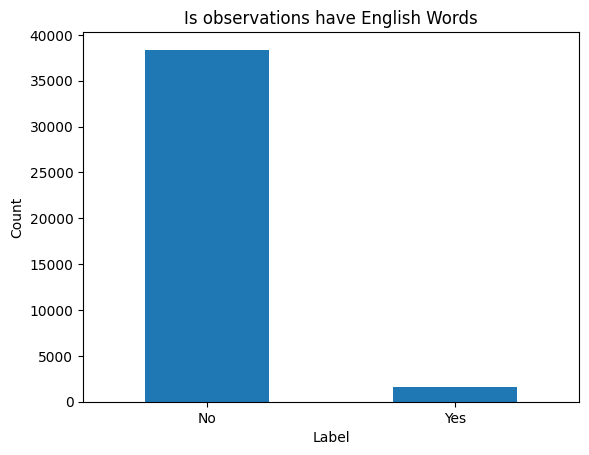

In [94]:
df['is_have_english_words'].value_counts().plot(kind='bar')
plt.title('Is observations have English Words')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'],rotation=0)
plt.show()

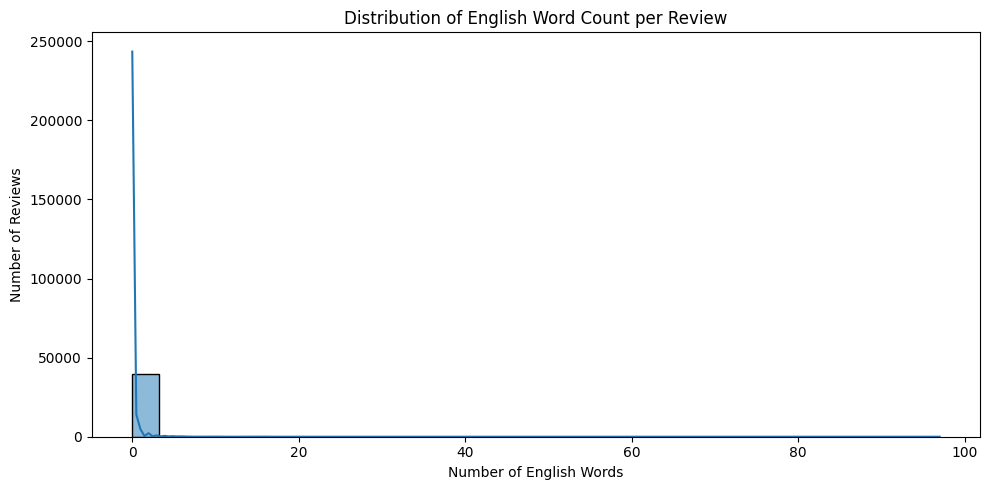

In [95]:
plt.figure(figsize=(10, 5))
sns.histplot(df['number_english_words'], bins=30, kde=True)

plt.title('Distribution of English Word Count per Review')
plt.xlabel('Number of English Words')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

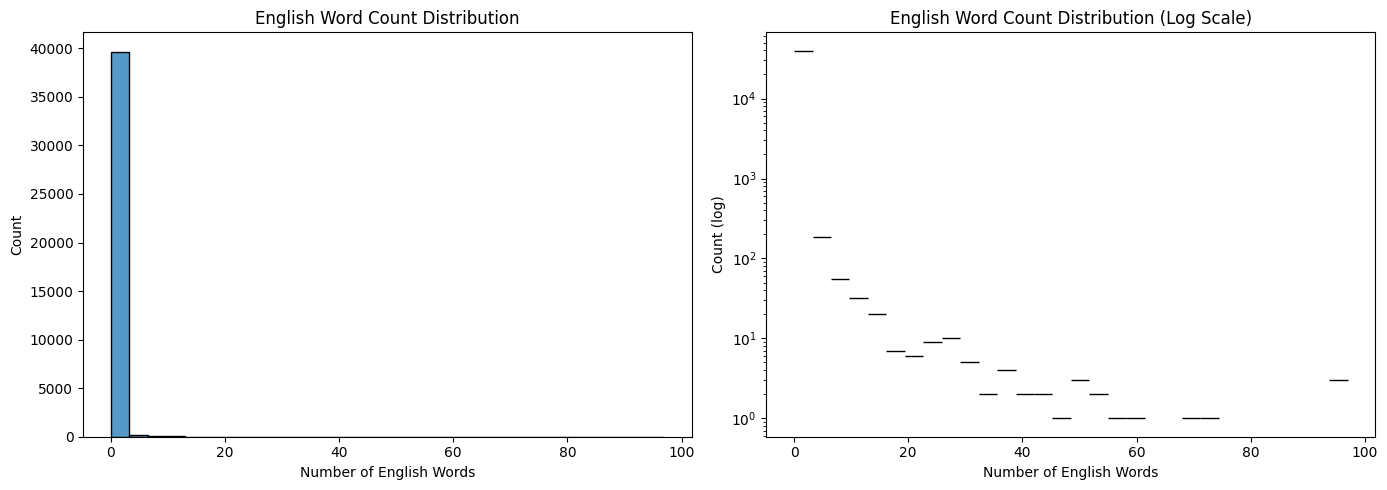

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal scale
sns.histplot(df['number_english_words'], bins=30, kde=False, ax=axes[0])
axes[0].set_title('English Word Count Distribution')
axes[0].set_xlabel('Number of English Words')
axes[0].set_ylabel('Count')

# Log scale (better when data is skewed)
sns.histplot(df['number_english_words'], bins=30, kde=False, ax=axes[1], log_scale=(False, True))
axes[1].set_title('English Word Count Distribution (Log Scale)')
axes[1].set_xlabel('Number of English Words')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
# plt.savefig('plots/english_word_count_dist.png', dpi=150)
plt.show()

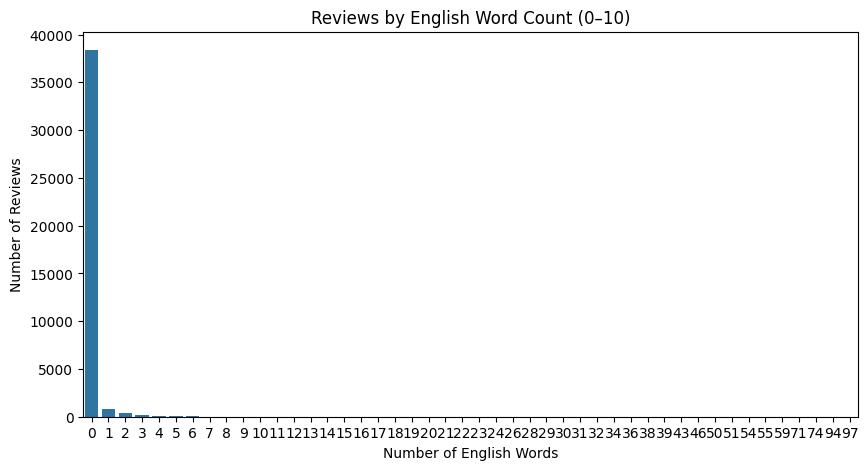

In [97]:
counts = df['number_english_words'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Reviews by English Word Count (0–10)')
plt.xlabel('Number of English Words')
plt.ylabel('Number of Reviews')
plt.show()

In [98]:
df[df['number_english_words']==1]

,review_description,rating,company,number_english_words,is_have_english_words
43,اسعار أعلى بنسب تتجاوز ال٧٠٪ من المطاعم تجارب ...,-1,talbat,1,1
67,Wo 🙌🙌💋💋💋💋💋💋💙💙💙❤❤💖💖💖👍👍👍👌,1,talbat,1,1
81,ugg,1,talbat,1,1
120,Good,1,talbat,1,1
404,Jgc,1,talbat,1,1
...,...,...,...,...,...
39287,التطبيق عندي مش بيشتغل دايما كاتب opss علي اي ...,0,hilton,1,1
39364,بصراحه انا قضيت يوم ممتع thanks,1,hilton,1,1
39395,مع هذا ويتم تزوير Rk وتقليد السلك,0,elsewedy,1,1
39791,Yas,1,TMG,1,1


In [103]:
# 1. Word count
df['word_count'] = df['review_description'].apply(lambda x: len(x.split()))

# 2. Emoji count
df['emoji_count'] =  df['review_description'].apply(lambda x: emoji.emoji_count(x))

# 3. Punctuation count
df['punctuation_count'] =  df['review_description'].apply(
lambda x: sum(1 for c in x if c in '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')
)

# 4. Sentence count
df['sentence_count'] =  df['review_description'].apply(
lambda x: max(len(sent_tokenize(x)), 1) if x.strip() else 0
)

# 5. Average words per sentence
df['avg_words_per_sentence'] = df['word_count'] / df['sentence_count']

# ratio of english words to total words
df['english_ratio'] = df['number_english_words'] / df['word_count']



In [105]:
df.head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0


In [106]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,40017.0,0.242422,0.945079,-1.000000,-1.0,1.0,1.0,1.0
number_english_words,40017.0,0.149661,1.693183,0.000000,0.0,0.0,0.0,97.0
is_have_english_words,40017.0,0.040858,0.197963,0.000000,0.0,0.0,0.0,1.0
word_count,40017.0,9.375440,12.528210,1.000000,3.0,5.0,11.0,443.0
emoji_count,40017.0,0.476098,3.832018,0.000000,0.0,0.0,0.0,246.0
punctuation_count,40017.0,0.551316,7.766569,0.000000,0.0,0.0,0.0,495.0
sentence_count,40017.0,1.049854,0.444027,1.000000,1.0,1.0,1.0,46.0
avg_words_per_sentence,40017.0,8.896655,11.273583,0.333333,3.0,5.0,11.0,374.0
english_ratio,40017.0,0.030913,0.184469,0.000000,0.0,0.0,0.0,12.0


### How many words you have

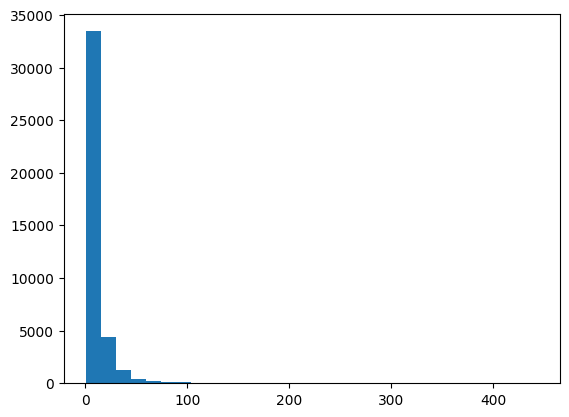

In [7]:
plt.hist(df['word_count'],bins=30)
plt.show()

In [11]:
df.head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...


In [13]:
!pip install arabic-reshaper python-bidi -q

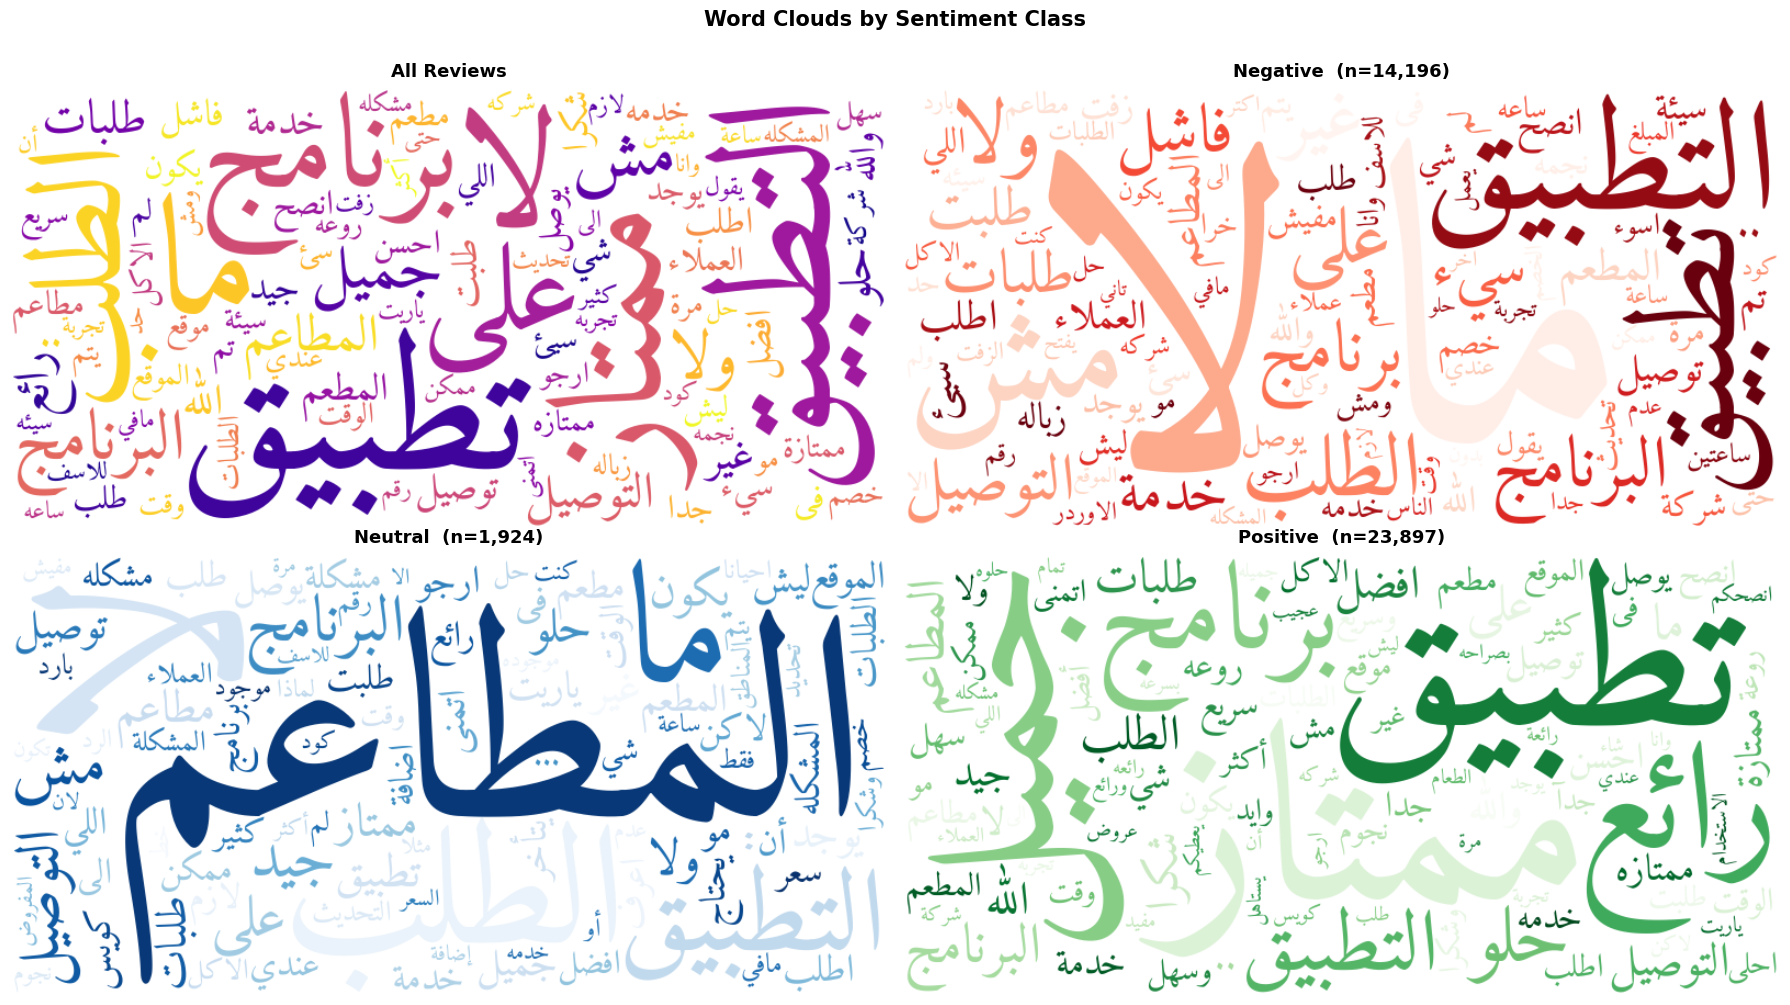

In [14]:
import os, urllib.request
from collections import Counter
import pandas as pd
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from src.utils import get_all_en_ara_stop_words

FONT_PATH = 'experiments/Amiri-Regular.ttf'
if not os.path.exists(FONT_PATH):
    os.makedirs('experiments', exist_ok=True)
    urllib.request.urlretrieve(
        'https://github.com/google/fonts/raw/main/ofl/amiri/Amiri-Regular.ttf',
        FONT_PATH
    )

ALL_STOPS = get_all_en_ara_stop_words()

def _reshape(word):
    """Fix Arabic letter joining and RTL direction."""
    return get_display(arabic_reshaper.reshape(word))

def make_wc(text, title, ax, colormap):
    # Tokenize + filter stopwords manually, then reshape each word
    tokens = [w for w in text.split() if w.lower() not in ALL_STOPS and len(w) > 1]
    freq   = Counter(tokens)

    # Reshape Arabic words so letters connect properly
    reshaped_freq = {_reshape(w): c for w, c in freq.most_common(100)}

    wc = WordCloud(
        font_path=FONT_PATH,
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
    ).generate_from_frequencies(reshaped_freq)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')

maps  = {-1: 'negative', 0: 'neutral', 1: 'positive'}
cmaps = {'negative': 'Reds', 'neutral': 'Blues', 'positive': 'Greens'}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Word Clouds by Sentiment Class', fontsize=15, fontweight='bold', y=1.01)

make_wc(' '.join(df['review_description'].dropna()), 'All Reviews', axes[0][0], 'plasma')

positions = [(0,1), (1,0), (1,1)]
for (r, c), (rating, label) in zip(positions, maps.items()):
    subset = df[df['rating'] == rating]['review_description'].dropna()
    make_wc(' '.join(subset), f'{label.capitalize()}  (n={len(subset):,})',
            axes[r][c], cmaps[label])

plt.tight_layout()
plt.savefig('experiments/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


here we can see most of our arabic words are MAS but there is also some of egyption dialect

In [107]:
import re
import emoji

def decode_emojies(text):

    if not isinstance(text, str) or text.strip() == "":
        return ""

    # 1. Decode emojis to their meaning
    text = emoji.demojize(text, delimiters=(" ", " "))


    text = re.sub(r'(?<=[a-z])_(?=[a-z])', ' ', text)  # replace underscores between words

    # 2. Remove extra whitespace left after decoding
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [108]:
df['decoded_emojis'] = df['review_description'].apply(decode_emojies)
df.head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...


### See the heatmap to check if these features affected our target column (rating) or not

In [110]:
df.select_dtypes(include='number').columns

Index(['rating', 'number_english_words', 'is_have_english_words', 'word_count',
       'emoji_count', 'punctuation_count', 'sentence_count',
       'avg_words_per_sentence', 'english_ratio'],
      dtype='object')

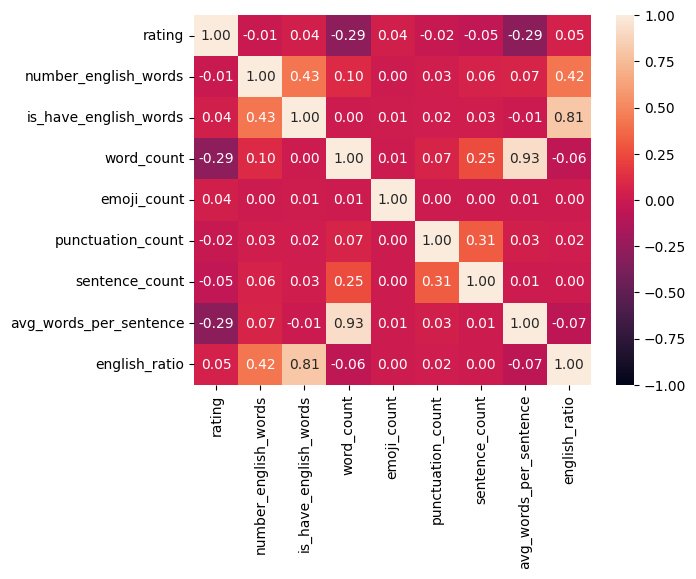

In [113]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,fmt='.2f',vmin=-1,vmax=1)
plt.show()

avg_words_per_sentence and word_count have low correlation, unlike others don't correlate at all

For training we will select decoded_emojis feature only and rating column as target

In [114]:
df.to_csv('df_eda.csv',index=False)

In [115]:
pd.read_csv('df_eda.csv').head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...


### Check augmented data

In [2]:
df_aug_train=pd.read_csv('data/2-train_df.csv')
df_aug_train.head()

,decoded_emojis,rating
0,فاشل وغير متوفر الاماكن في القاهرة البرامج موج...,-1
1,نحتاج الى لقطة شاشة من التطبيق عدم وجودها يجعل...,-1
2,خدمه سى,-1
3,زايرني شركه 🙏💜 قسمبالله زبااله وفشلهم مصداقية ...,-1
4,سيئ بيحج التطبيق التوصيل يتأخر,-1


In [4]:
df_org=pd.read_csv('data/0-CompanyReviews.csv')

In [5]:
df_train_check,df_test_check=train_test_split(df_org,stratify=df_org['rating'],random_state=42,shuffle=True)

df_train_check['rating'].value_counts()

rating
 1    17940
-1    10650
 0     1444
Name: count, dtype: int64

In [6]:
df_aug_train['rating'].value_counts()

rating
 1    17922
-1    14337
 0     5772
Name: count, dtype: int64

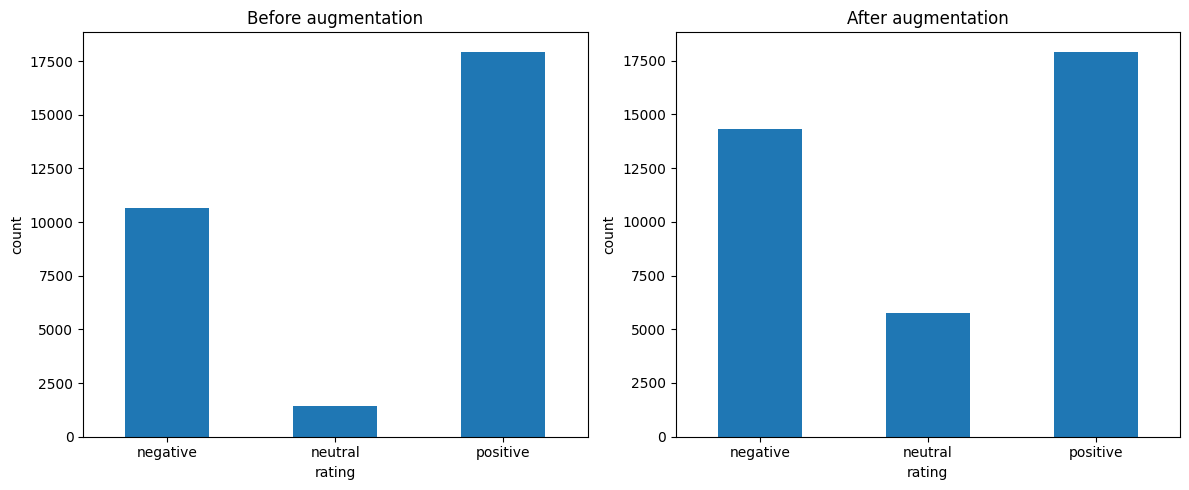

In [11]:
label_map = {-1: 'negative', 0: 'neutral', 1: 'positive'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vc1 = df_train_check['rating'].value_counts().sort_index()
vc1.plot(kind='bar', ax=axes[0])
axes[0].set_title('Before augmentation')
axes[0].set_xlabel('rating')
axes[0].set_ylabel('count')
axes[0].set_xticklabels([label_map[r] for r in vc1.index], rotation=0)

vc2 = df_aug_train['rating'].value_counts().sort_index()
vc2.plot(kind='bar', ax=axes[1])
axes[1].set_title('After augmentation')
axes[1].set_xlabel('rating')
axes[1].set_ylabel('count')
axes[1].set_xticklabels([label_map[r] for r in vc2.index], rotation=0)

plt.tight_layout()
plt.show()

### See traditional preprocessing data

In [1]:
import pandas as pd

def clean_and_save(path, label):
    df = pd.read_csv(path)
    before = len(df)
    df.dropna(inplace=True)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    df.to_csv(path, index=False)
    print(f"{label}: {before} → {len(df)} rows  (removed {before - len(df)})")
    return df

# ── df 2 (augmented) ──────────────────────────────────────────────────────────
clean_and_save('data/2-train_df.csv', '2-train')
clean_and_save('data/2-test_df.csv',  '2-test')

# ── df 3 (traditional preprocessed) ──────────────────────────────────────────
clean_and_save('data/3-proc_train_df.csv', '3-train')
clean_and_save('data/3-proc_test_df.csv',  '3-test')

# ── df 4 (transformer preprocessed) ──────────────────────────────────────────
clean_and_save('data/4-trans_prepr_train_df.csv', '4-train')
clean_and_save('data/4-trans_prepr_test_df.csv',  '4-test')


2-train: 38031 → 37164 rows  (removed 867)
2-test: 10005 → 9935 rows  (removed 70)
3-train: 38031 → 33926 rows  (removed 4105)
3-test: 10005 → 9092 rows  (removed 913)
4-train: 38031 → 36589 rows  (removed 1442)
4-test: 10005 → 9803 rows  (removed 202)


,decoded_emojis,rating
0,.. كل,1
1,ولله مرره حلو وبرنامج روعه لكل الأذواق !,1
2,ممتاز جدا جدا,1
3,ممتاز في التعامل,1
4,برنامج باله بقد ساعه عشان وجبه face with rolli...,-1
...,...,...
9798,اختصرت علي انتظار المطاعم وسهولة تعاملك kissin...,1
9799,اقتراح إضافة خدمةGPS إرسال الموقع,0
9800,خدمة معقوله.,1
9801,برنامج رائع جدا شكرا لكم,1


In [41]:
df_fixed=pd.read_csv(r'data/1-df_fixed.csv')

In [44]:
df_fixed.head()

,Unnamed: 0,new_rating,decoded_emojis
0,45,1,تجربه مرضيه والتوصيل كان كويس ومعقول
1,50,1,بصراحة تغيير كبير في سياسة طلبات مع الزبائن، ه...
2,56,-1,لماذة لا استطيع استخدام القسائم
3,66,1,جيد جدا
4,73,0,3w2d32d32


In [45]:
df_eda=pd.read_csv(r'data/1-df_eda.csv')
df_eda.head()

,review_description,rating,company,number_english_words,is_have_english_words,word_count,emoji_count,punctuation_count,sentence_count,avg_words_per_sentence,english_ratio,decoded_emojis
0,رائع,1,talbat,0,0,1,0,0,1,1.0,0.0,رائع
1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat,0,0,9,0,0,1,9.0,0.0,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...
2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat,0,0,15,0,4,2,7.5,0.0,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...
3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat,0,0,6,0,0,1,6.0,0.0,لماذا لا يمكننا طلب من ماكدونالدز؟
4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat,0,0,15,0,0,1,15.0,0.0,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...


In [48]:
df_eda.loc[45]

review_description        تجربه مرضيه والتوصيل كان كويس ومعقول
rating                                                       0
company                                                 talbat
number_english_words                                         0
is_have_english_words                                        0
word_count                                                   6
emoji_count                                                  0
punctuation_count                                            0
sentence_count                                               1
avg_words_per_sentence                                     6.0
english_ratio                                              0.0
decoded_emojis            تجربه مرضيه والتوصيل كان كويس ومعقول
Name: 45, dtype: object